<a href="https://colab.research.google.com/github/kosar-am/day-night-road-cyclegan/blob/main/notebooks/01_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day-to-Night Road Scene Translation using CycleGAN

## Dataset Exploration

In this notebook, we will:

- Load the BDD100K dataset
- Explore the dataset structure
- Visualize day and night road scenes
- Understand the dataset before preprocessing

# Import Libraries

In [34]:
# Import the required libraries

import os
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

# Load Dataset

In [2]:
# Download the BDD100K dataset from Kaggle
dataset_path = kagglehub.dataset_download("alvaromalfaro/bdd100k")

print("Dataset path:", dataset_path)

100%|██████████| 5.46G/5.46G [01:00<00:00, 96.4MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1


# Explore Dataset Structure

In [3]:
# Convert the dataset path to a Path object
dataset_path = Path(dataset_path)

# Display the dataset path
print(dataset_path)

/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1


In [4]:
# List all files and folders in the dataset
for item in dataset_path.iterdir():
    print(item)

/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k


In [5]:
# Access the main dataset directory
dataset_path = dataset_path / "bdd100k"

# Display the dataset path
print(dataset_path)

/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k


In [6]:
# List all files and folders inside the dataset
for item in dataset_path.iterdir():
    print(item)

/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/labels
/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/images


In [7]:
# List the contents of the images directory
images_path = dataset_path / "images"

for item in images_path.iterdir():
    print(item)

/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/images/100k


In [9]:
# List the contents of the image dataset
images_path = dataset_path / "images" / "100k"

for item in images_path.iterdir():
    print(item)

/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/images/100k/val
/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/images/100k/test
/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/images/100k/train


In [8]:
# List the contents of the labels directory
labels_path = dataset_path / "labels"

for item in labels_path.iterdir():
    print(item)

/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/labels/val
/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/labels/test
/root/.cache/kagglehub/datasets/alvaromalfaro/bdd100k/versions/1/bdd100k/labels/train


## Analysis

The BDD100K dataset follows a hierarchical directory structure that separates images and labels into dedicated folders. The image dataset is further divided into training, validation, and test subsets.

```text
bdd100k/
│
├── images/
│   └── 100k/
│       ├── train/
│       ├── val/
│       └── test/
│
└── labels/
    ├── train/
    ├── val/
    └── test/
```

# Visualize Sample Images

In [10]:
# Define the paths for the training images
train_path = dataset_path / "images" / "100k" / "train"

# Display the total number of training images
train_images = sorted(train_path.glob("*.jpg"))

print(f"Total training images: {len(train_images)}")

Total training images: 70000


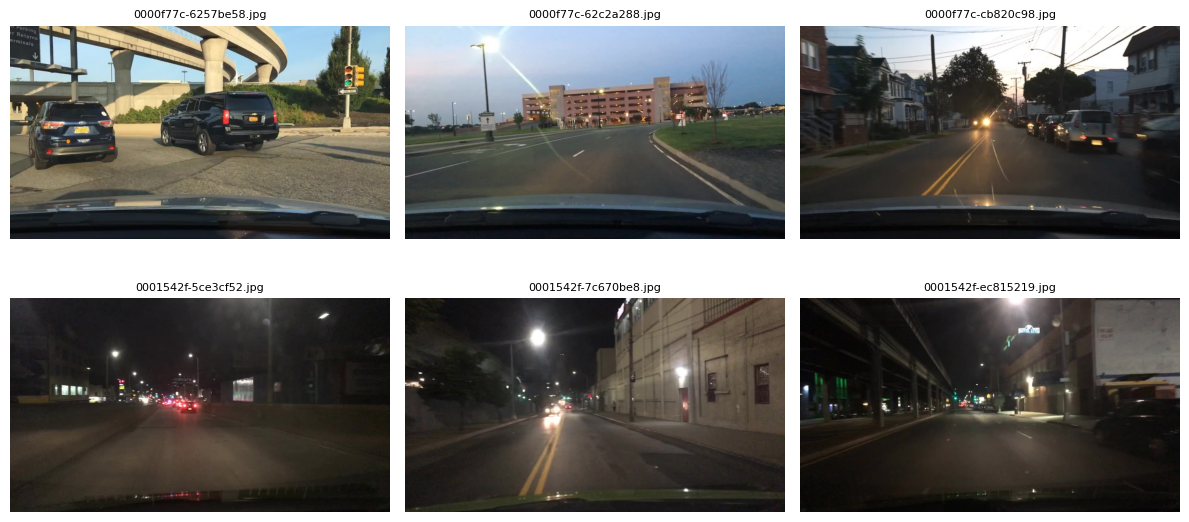

In [13]:
# Display six sample images from the training set
sample_images = train_images[:6]

plt.figure(figsize=(12, 6))

for i, image_path in enumerate(sample_images):
    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(image_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Inspect Image Properties

In [14]:
# Load the first training image
sample_image = Image.open(train_images[0])

# Display basic image properties
print(f"Image Size      : {sample_image.size}")
print(f"Image Mode      : {sample_image.mode}")
print(f"Image Format    : {sample_image.format}")

Image Size      : (1280, 720)
Image Mode      : RGB
Image Format    : JPEG


# Analysis

The sample image has a resolution of **1280 × 720** pixels in **RGB** format and is stored as a **JPEG** file. These properties make the dataset suitable for computer vision tasks, although the images will likely be resized during preprocessing.

# Check Image Consistency

In [15]:
# Check the properties of the first six training images
for image_path in train_images[:6]:
    image = Image.open(image_path)

    print(
        f"{image_path.name}\n"
        f"  Size   : {image.size}\n"
        f"  Mode   : {image.mode}\n"
        f"  Format : {image.format}\n"
    )

0000f77c-6257be58.jpg
  Size   : (1280, 720)
  Mode   : RGB
  Format : JPEG

0000f77c-62c2a288.jpg
  Size   : (1280, 720)
  Mode   : RGB
  Format : JPEG

0000f77c-cb820c98.jpg
  Size   : (1280, 720)
  Mode   : RGB
  Format : JPEG

0001542f-5ce3cf52.jpg
  Size   : (1280, 720)
  Mode   : RGB
  Format : JPEG

0001542f-7c670be8.jpg
  Size   : (1280, 720)
  Mode   : RGB
  Format : JPEG

0001542f-ec815219.jpg
  Size   : (1280, 720)
  Mode   : RGB
  Format : JPEG



# Analysis

The inspected images have the same resolution (**1280 × 720**), color mode (**RGB**), and file format (**JPEG**). This consistency simplifies preprocessing and data loading.

# Explore Labels

In [17]:
# Display the number of label files
train_labels_path = dataset_path / "labels" / "train"

label_files = sorted(train_labels_path.glob("*"))

print(f"Total label files: {len(label_files)}")
print(f"\nFirst label file: {label_files[0].name}")
print(f"Last label file : {label_files[-1].name}")

Total label files: 70000

First label file: 0000f77c-6257be58.json
Last label file : fe189115-8dabb5b1.json


In [18]:
# Display the unique file extensions
extensions = sorted({file.suffix for file in label_files})

print("File extensions:", extensions)

File extensions: ['.json']


# Inspect Label File

In [19]:
# Import the JSON library
import json

# Load the first label file
with open(label_files[0], "r") as file:
    label_data = json.load(file)

# Display the top-level keys
print(label_data.keys())

dict_keys(['name', 'frames', 'attributes'])


## Analysis

The label file contains three main sections: **name**, **frames**, and **attributes**. This structure organizes image metadata, frame annotations, and scene-level information in a structured JSON format.

In [20]:
# Display the data type of each top-level field
for key, value in label_data.items():
    print(f"{key}: {type(value)}")

name: <class 'str'>
frames: <class 'list'>
attributes: <class 'dict'>


In [21]:
# Display the number of frames
print(f"Number of frames: {len(label_data['frames'])}")

Number of frames: 1


# Analysis

Each label file contains **one frame**, indicating that every JSON file corresponds to a single image and its annotations.

# Explore Frame Structure

In [22]:
# Display the keys of the first frame
print(label_data["frames"][0].keys())

dict_keys(['timestamp', 'objects'])


# Analysis

Each frame contains a **timestamp** and a collection of **objects**. The `objects` field stores the annotations for all labeled instances in the image.

# Inspect Objects

In [23]:
# Display the number of annotated objects
objects = label_data["frames"][0]["objects"]

print(f"Number of objects: {len(objects)}")

Number of objects: 11


# Analysis

The first image contains **11 annotated objects**, indicating that multiple road participants and scene elements are labeled within a single frame.

# Inspect Object Structure

In [24]:
# Display the structure of the first annotated object
print(objects[0])

{'category': 'traffic light', 'id': 0, 'attributes': {'occluded': False, 'truncated': False, 'trafficLightColor': 'green'}, 'box2d': {'x1': 1125.902264, 'y1': 133.184488, 'x2': 1156.978645, 'y2': 210.875445}}


In [25]:
{
    'category': 'traffic light',
    'id': 0,
    'attributes': {
        'occluded': False,
        'truncated': False,
        'trafficLightColor': 'green'
    },
    'box2d': {
        'x1': 1125.902264,
        'y1': 133.184488,
        'x2': 1156.978645,
        'y2': 210.875445
    }
}

{'category': 'traffic light',
 'id': 0,
 'attributes': {'occluded': False,
  'truncated': False,
  'trafficLightColor': 'green'},
 'box2d': {'x1': 1125.902264,
  'y1': 133.184488,
  'x2': 1156.978645,
  'y2': 210.875445}}

# Analysis

Each object annotation consists of four main components:

- **category**: The object class.
- **id**: A unique identifier for the object.
- **attributes**: Additional information about the object.
- **box2d**: The 2D bounding box coordinates.

# Visualize Bounding Box

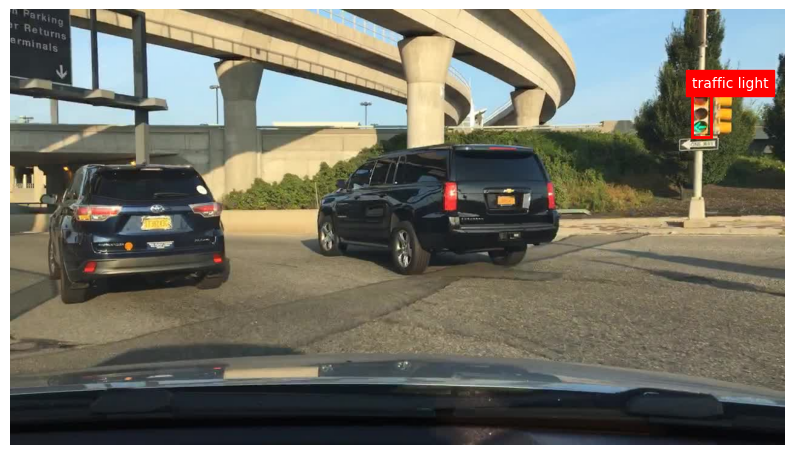

In [28]:
# Load the first training image
image = Image.open(train_images[0])

# Get the first annotated object
first_object = objects[0]

# Extract bounding box coordinates
bbox = first_object["box2d"]

x1 = bbox["x1"]
y1 = bbox["y1"]
x2 = bbox["x2"]
y2 = bbox["y2"]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 6))

# Display the image
ax.imshow(image)

# Draw the bounding box
rectangle = patches.Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
)

ax.add_patch(rectangle)

# Display the object category
ax.text(
    x1,
    y1 - 5,
    first_object["category"],
    color="white",
    fontsize=10,
    backgroundcolor="red",
)

ax.axis("off")
plt.show()

# Visualize All Bounding Boxes

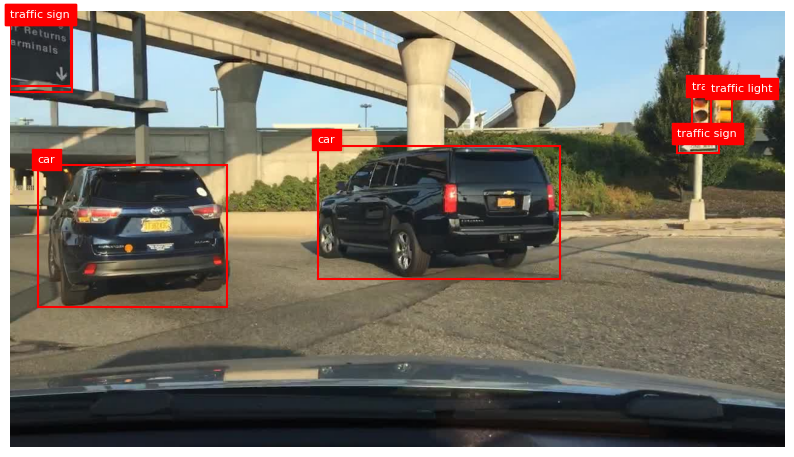

In [29]:
# Display all annotated objects in the first image
fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(image)

for obj in objects:
    bbox = obj.get("box2d")

    # Skip objects without a 2D bounding box
    if bbox is None:
        continue

    x1 = bbox["x1"]
    y1 = bbox["y1"]
    x2 = bbox["x2"]
    y2 = bbox["y2"]

    rectangle = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=1.5,
        edgecolor="red",
        facecolor="none",
    )

    ax.add_patch(rectangle)

    ax.text(
        x1,
        max(y1 - 5, 10),
        obj["category"],
        color="white",
        fontsize=8,
        backgroundcolor="red",
    )

ax.axis("off")
plt.show()

# Explore Object Categories

In [30]:
# Extract the categories from all annotated objects in the first image
categories = [obj["category"] for obj in objects]

# Display the categories
print(categories)

['traffic light', 'traffic light', 'traffic sign', 'traffic sign', 'car', 'car', 'traffic sign', 'area/drivable', 'lane/road curb', 'lane/road curb', 'lane/road curb']


In [31]:
# Display the unique categories in the first image
unique_categories = sorted(set(categories))

print(unique_categories)

['area/drivable', 'car', 'lane/road curb', 'traffic light', 'traffic sign']


## Analysis

The first image contains **5 unique object categories**. Some categories appear multiple times, indicating that a single image can include several instances of the same object class.

# Count Object Categories

In [32]:
# Count the number of objects in each category
from collections import Counter

category_counts = Counter(categories)

print(category_counts)

Counter({'traffic sign': 3, 'lane/road curb': 3, 'traffic light': 2, 'car': 2, 'area/drivable': 1})


## Analysis

The first image contains **11 annotated objects** belonging to **5 different categories**. The most frequent categories are **traffic sign** and **lane/road curb**, each appearing three times.

# Analyze Object Categories Across the Entire Training Set

In [33]:
# Collect all training label files
label_files = sorted(train_labels_path.glob("*.json"))

print(f"Total label files: {len(label_files)}")

Total label files: 70000


In [35]:

# Initialize the category counter
all_category_counts = Counter()

# Iterate through all label files
for label_file in label_files:

    with open(label_file, "r") as file:
        label = json.load(file)

    for obj in label["frames"][0]["objects"]:
        all_category_counts[obj["category"]] += 1

In [36]:
# Display the ten most common object categories
all_category_counts.most_common(10)

[('car', 714121),
 ('lane/single white', 247108),
 ('traffic sign', 239961),
 ('traffic light', 186301),
 ('lane/road curb', 109868),
 ('lane/crosswalk', 108284),
 ('person', 91435),
 ('area/drivable', 64050),
 ('area/alternative', 61799),
 ('lane/double yellow', 37519)]

## Analysis

The training dataset contains **70,000** labeled images. The most common object category is **car**, followed by lane markings, traffic signs, and traffic lights. This indicates that the dataset is highly focused on autonomous driving scenarios.

# Visualize Object Category Distribution

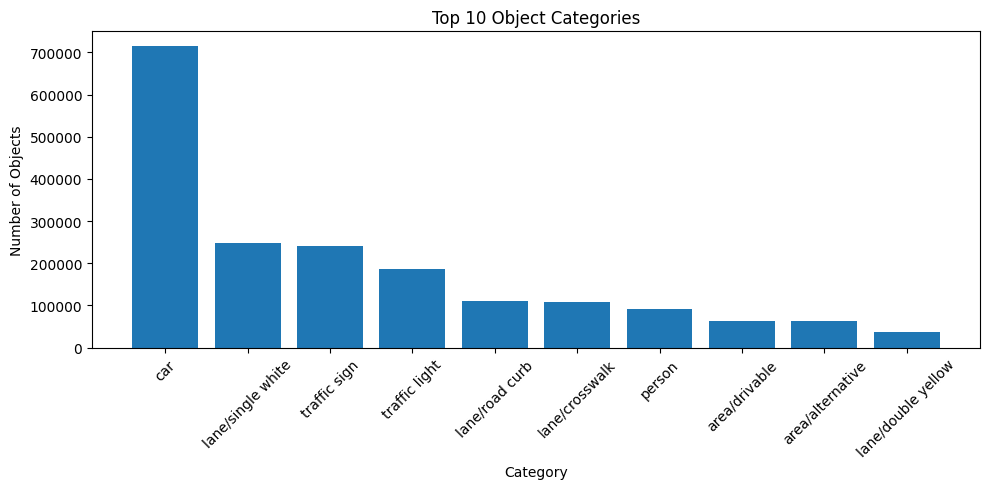

In [37]:
# Select the ten most common object categories
top_categories = all_category_counts.most_common(10)

categories = [item[0] for item in top_categories]
counts = [item[1] for item in top_categories]

# Create a bar chart
plt.figure(figsize=(10, 5))

plt.bar(categories, counts)

plt.title("Top 10 Object Categories")
plt.xlabel("Category")
plt.ylabel("Number of Objects")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Explore Image Attributes

In [38]:
# Display the image-level attributes
label_data["attributes"]

{'weather': 'clear', 'scene': 'city street', 'timeofday': 'daytime'}

# Analyze Image Attributes

In [39]:
# Initialize counters for image attributes
weather_counts = Counter()
scene_counts = Counter()
timeofday_counts = Counter()

# Iterate through all label files
for label_file in label_files:

    with open(label_file, "r") as file:
        label = json.load(file)

    attributes = label["attributes"]

    weather_counts[attributes["weather"]] += 1
    scene_counts[attributes["scene"]] += 1
    timeofday_counts[attributes["timeofday"]] += 1

In [40]:
# Display the time-of-day distribution
print(timeofday_counts)

Counter({'daytime': 36800, 'night': 28028, 'dawn/dusk': 5033, 'undefined': 139})


In [41]:
# Display the weather distribution
print(weather_counts)

Counter({'clear': 37412, 'overcast': 8784, 'undefined': 8134, 'snowy': 5571, 'rainy': 5083, 'partly cloudy': 4886, 'foggy': 130})


In [42]:
# Display the scene distribution
print(scene_counts)

Counter({'city street': 43581, 'highway': 17414, 'residential': 8105, 'parking lot': 378, 'undefined': 366, 'tunnel': 129, 'gas stations': 27})


## Analysis

The dataset includes images captured under different weather conditions, scene types, and times of day. Most images are collected during **daytime**, under **clear weather**, and in **city street** environments. This diversity makes the dataset suitable for autonomous driving and image translation tasks.


# Dataset Summary

| Property | Value |
|----------|------:|
| Dataset | BDD100K |
| Training Images | 70,000 |
| Image Resolution | 1280 × 720 |
| Image Format | JPEG |
| Color Mode | RGB |
| Annotation Format | JSON |
| Total Object Categories | 41 |
| Most Common Object | Car (714,121) |
| Time of Day | Day, Night, Dawn/Dusk |
| Weather Conditions | Clear, Overcast, Rainy, Snowy, Foggy, Partly Cloudy |
| Scene Types | City Street, Highway, Residential, Parking Lot, Tunnel, Gas Station |
| Primary Application | Autonomous Driving |


# Key Findings

- The dataset contains 70,000 annotated driving images.
- Images have a consistent resolution of **1280 × 720** pixels.
- All annotations are stored in **JSON** format.
- **Car** is the most frequent object category.
- The dataset includes **28,028 nighttime images**, making it suitable for image translation tasks.
- Images cover multiple weather conditions and driving environments.
- The dataset provides rich annotations for autonomous driving applications.

# Conclusion

The BDD100K dataset was thoroughly explored to understand its structure, annotations, and visual characteristics before model development.

The analysis showed that the dataset contains 70,000 high-resolution driving images with comprehensive object annotations and diverse environmental conditions. Images cover multiple weather scenarios, times of day, and driving environments, making the dataset well suited for autonomous driving research.

The exploratory analysis also confirmed that the dataset provides a large number of daytime and nighttime images, which makes it an excellent choice for the CycleGAN-based day-to-night and night-to-day image translation project developed in this repository.

